<a href="https://colab.research.google.com/github/AmalKhairalla/Online-News-Popularity/blob/main/Data_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading Data

In [1]:
from google.colab import files

uploaded = files.upload()

Saving OnlineNewsPopularity.csv to OnlineNewsPopularity.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'OnlineNewsPopularity.csv'
df = pd.read_csv(file_path)

Memory usage analysis

In [3]:
memory_usage = df.memory_usage(deep=True).sum() / 1024**2

print(f"Total Memory Usage: {memory_usage:.2f} MB")

Total Memory Usage: 22.18 MB


In [26]:
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32')

for col in df.select_dtypes(include=['int64']).columns:
    df[col] = df[col].astype('int32')

#EDA

In [27]:
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,log_shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593,6.386879
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711,6.568078
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500,7.313887
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200,7.090910
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505,6.226537


In [28]:
print("Shape of dataset:", df.shape)

Shape of dataset: (39644, 62)


In [29]:
df.columns

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

In [30]:
df.dtypes

,0
url,object
timedelta,float32
n_tokens_title,float32
n_tokens_content,float32
n_unique_tokens,float32
...,...
title_sentiment_polarity,float32
abs_title_subjectivity,float32
abs_title_sentiment_polarity,float32
shares,int32


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 62 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            39644 non-null  object 
 1   timedelta                      39644 non-null  float32
 2   n_tokens_title                 39644 non-null  float32
 3   n_tokens_content               39644 non-null  float32
 4   n_unique_tokens                39644 non-null  float32
 5   n_non_stop_words               39644 non-null  float32
 6   n_non_stop_unique_tokens       39644 non-null  float32
 7   num_hrefs                      39644 non-null  float32
 8   num_self_hrefs                 39644 non-null  float32
 9   num_imgs                       39644 non-null  float32
 10  num_videos                     39644 non-null  float32
 11  average_token_length           39644 non-null  float32
 12  num_keywords                   39644 non-null 

In [32]:
missing_values = df.isnull().sum()

missing_values

,0
url,0
timedelta,0
n_tokens_title,0
n_tokens_content,0
n_unique_tokens,0
...,...
title_sentiment_polarity,0
abs_title_subjectivity,0
abs_title_sentiment_polarity,0
shares,0


In [33]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
timedelta,39644.0,354.530457,214.165253,8.000000,164.000000,339.000000,542.000000,731.00000
n_tokens_title,39644.0,10.398748,2.113835,2.000000,9.000000,10.000000,12.000000,23.00000
n_tokens_content,39644.0,546.514709,471.106293,0.000000,246.000000,409.000000,716.000000,8474.00000
n_unique_tokens,39644.0,0.548216,3.520675,0.000000,0.470870,0.539226,0.608696,701.00000
n_non_stop_words,39644.0,0.996469,5.231244,0.000000,1.000000,1.000000,1.000000,1042.00000
...,...,...,...,...,...,...,...,...
title_sentiment_polarity,39644.0,0.071425,0.265466,-1.000000,0.000000,0.000000,0.150000,1.00000
abs_title_subjectivity,39644.0,0.341843,0.188803,0.000000,0.166667,0.500000,0.500000,0.50000
abs_title_sentiment_polarity,39644.0,0.156064,0.226323,0.000000,0.000000,0.000000,0.250000,1.00000
shares,39644.0,3395.380184,11626.950749,1.000000,946.000000,1400.000000,2800.000000,843300.00000


In [35]:
numeric_cols = df.select_dtypes(include=np.number).columns

print(numeric_cols)

Index(['timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens',
       'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs',
       'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length',
       'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
       'glob

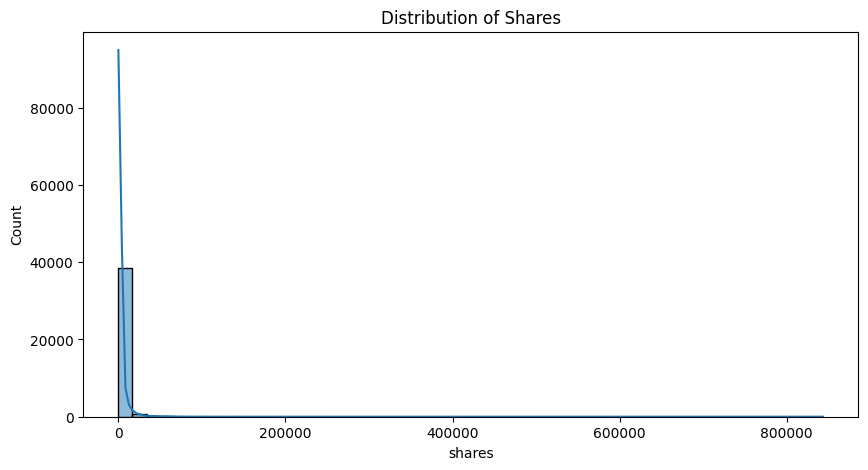

In [37]:
plt.figure(figsize=(10,5))

sns.histplot(df['shares'], bins=50, kde=True)

plt.title("Distribution of Shares")
plt.show()

In [ ]:
print(df['shares'].skew())

In [ ]:
plt.figure(figsize=(12,5))

sns.boxplot(x=df['shares'])

plt.title("Boxplot of Shares")

plt.show()

In [ ]:
Q1 = df['shares'].quantile(0.25)
Q3 = df['shares'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['shares'] < lower_bound) |
    (df['shares'] > upper_bound)
]

print("Number of outliers:", outliers.shape[0])

#Preprocessing

In [38]:
df['log_shares'] = np.log1p(df['shares'])

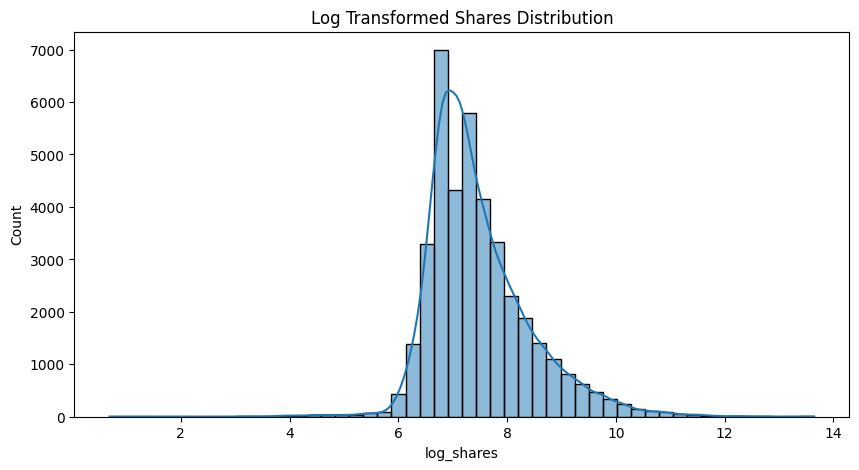

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(df['log_shares'], bins=50, kde=True)

plt.title("Log Transformed Shares Distribution")

plt.show()

In [40]:
print("Before:", df['shares'].skew())

print("After:", df['log_shares'].skew())

Before: 33.96388487571415
After: 1.0264770065011177


#Feature Scaling